In [1]:
import functions as fn
from mastu import HSV
import numpy as np
import sys

In [2]:
plot = True

In [3]:
### load the dictionary
dictFile = '/home/sthoma/tokamak_inversion_routines/Dictionaries/inputDict50499.txt'
inputDict = fn.loadDict(dictFile)

### unzip the dictionary
shotn = inputDict['shotn']
Rzfile = inputDict['Rzfile']
maskFile = inputDict['maskFile']

### the inputs to select which bits of video, and averaging
I0 = inputDict['I0']
I1 = inputDict['I1']
J0 = inputDict['J0']
J1 = inputDict['J1']
tend = inputDict['tend']
raverage = inputDict['raverage']
taverage = inputDict['taverage']
# T0 = inputDict['T0']
# T1 = inputDict['T1']
T0 = 500
T1 = 510

### for converting to photons and account for vignetting
photons = bool(inputDict['photons'])
exposureMult = inputDict['exposureMult']
vignette = bool(inputDict['vignette'])

### variables for the inversion, should be approximately constant
saveFile = inputDict['saveFile']
rEnd = inputDict['rEnd']
nrMult = inputDict['nrMult']
sysErr = inputDict['sysErr']
photon = bool(inputDict['photon'])
biasedEdges = bool(inputDict['biasedEdges'])
nFisher = inputDict['nFisher']
regGuess = inputDict['regGuess']
regMin = inputDict['regMin']

### use pedestal fitting or raw Thomson
kindThomson = inputDict['kindThomson']
### R value pedestal fitting works up to
Rprofile0 = inputDict['Rprofile0']

### kind of interpolation to use, don't need to change
line = inputDict['line']
kindExcite = inputDict['kindExcite']
kindRecomb = inputDict['kindRecomb']
kindIonise = inputDict['kindIonise']

### using a constant percentage for profile error
percent = inputDict['percent']

### temperature to assume for neutral density from fig
figTemp = inputDict['figTemp']

In [4]:
### load the Rz coordinates
R0, z0 = HSV.getRz(Rzfile, I0, I1, J0, J1)

### prepping R, adding extra, and flipping
R, goodChans, flipBool = fn.prepR(R0, rEnd)
### grid to interpolate onto
nGrid = int(len(R0) * nrMult)
Rgrid, RgridB = fn.makeGrid(R, nGrid)
### making dL
dL = fn.makeDL(Rgrid, R)

In [5]:
### quicker than loading the whole dataset
trange = HSV.makeTimeRange(shotn, T0, T1)
### load the data from UDA
rawData, time = HSV.get(shotn, trange=trange)

### 
dSlice = (slice(I0,I1), slice(J0,J1), slice(0,len(time)))
data, err = HSV.prepData(
    shotn, rawData, dSlice, goodChans, flipBool, 
    rEnd, tend, sysErr=sysErr, photon=photon
)
### average in space and time if wanted
if raverage:
    data = HSV.makeRadialAverage(data, raverage, rEnd)
    err = HSV.makeRadialAverage(err, raverage, rEnd)
if taverage:
    data = HSV.makeTimeAverage(data, taverage)
    err = HSV.makeTimeAverage(err, taverage)

# ### chop down to selected time range
# tSlice = slice(T0, T1)
# data = data[tSlice,:]
# err = err[tSlice,:]
# time = time[tSlice]

### convert to ph m^-2 sr^-1
if photons:
    data, err = HSV.applyCalibration(data, err, inputDict)

### convert to ph m^-2 sr^-1 s^-1
data, err = HSV.applyExposure(data, err, shotn, mult=exposureMult)

### apply vignette function
if vignette:
    data, err = HSV.applyVignette(
        data, err, inputDict, shotn, dSlice[:-1], flipBool, rEnd
    )

### sizes of data
nT, nR = data.shape
### scale so not working with large numbers
scale = fn.makeScale(data)

In [6]:
### load the mask if using one
try:
    mask = HSV.loadMask(maskFile, flipBool, rEnd)
except TypeError as e:
    print('No maskFile, not using a mask')
    mask = np.ones(data.shape[1]).astype(bool)

### make the regularisation band matrix
D = fn.regulMatrix(nGrid, biasedEdges=biasedEdges)
### making empty arrays for results
emissivity = np.zeros((nT, nGrid-1))
emissivityErr = np.zeros((nT, nGrid-1))
chi2 = np.zeros(nT)
gamma = np.zeros(nT)
backprojection = np.zeros((nT, nR))
### empty arrays for measurements of the emissivity profile
emMax = np.zeros(nT)
emMaxR = np.zeros(nT)
emR0 = np.zeros(nT)
emR1 = np.zeros(nT)
emFWHM = np.zeros(nT)
emFWHMerr = np.zeros(nT)

### arrays of indices, used in each iteration
indLos = slice(0, nR)
indSpace = slice(0, nGrid-1)
### linspace, used in each iteration
# Q = np.linspace(0., 1., indLos.stop-indLos.start)
Q = np.linspace(0., 1., np.count_nonzero(mask))

### make R array for profiles.
### Rprofile needed later, Rind needed now
Rind = fn.findNearest(RgridB, Rprofile0)
Rprofile = RgridB[Rind:]

### iterate over the times
for i in range(nT):
    emissivity[i,indSpace], emissivityErr[i,indSpace], backprojection[i,mask], \
        chi2[i], gamma[i] = fn.inversion(
            data[i][mask], err[i][mask], dL[mask,:], scale, nGrid, Q, D, 
            indLos, indSpace, nFisher=nFisher, regGuess=regGuess, regMin=regMin
    )

    ### multiply the answers by scale
    emissivity[i] *= scale
    emissivityErr[i] *= scale

    ### find the emissivity maximum and location
    emMax[i] = emissivity[i][Rind:].max()
    emMaxR[i] = Rprofile[emissivity[i][Rind:].argmax()]

    ### calculate the emissivity FWHM
    emR0[i], emR1[i] = fn.findPosition(
        Rprofile, emissivity[i][Rind:], 0.5, kind='linear'
    )
    emFWHM[i] = emR1[i] - emR0[i]
    emFWHMerr[i] = fn.findPositionErr(
        Rprofile, emissivity[i][Rind:], emissivityErr[i][Rind:],
        0.5, x0=emR0[i], x1=emR1[i], kind='linear'
    )

/home/sthoma/tokamak_inversion_routines/functions.py:196: RuntimeWarning: invalid value encountered in multiply
  backprojection = fit = np.dot(p*w, U.T) * err


In [7]:
print('done')

done


In [8]:
%matplotlib widget

In [9]:
import plotFunctions as pf

In [10]:
fills = pf.makeFills(mask, R)

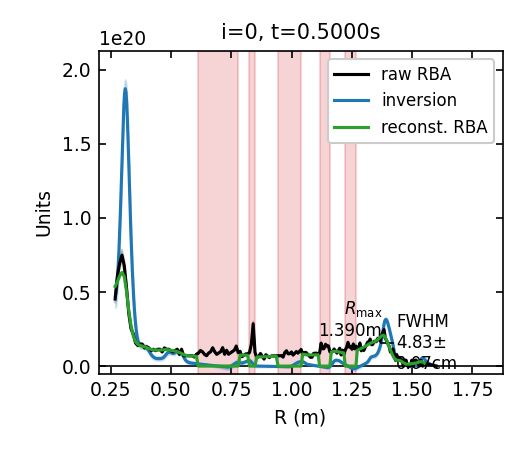

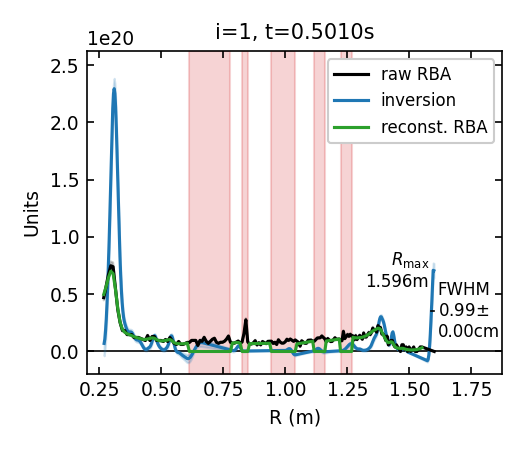

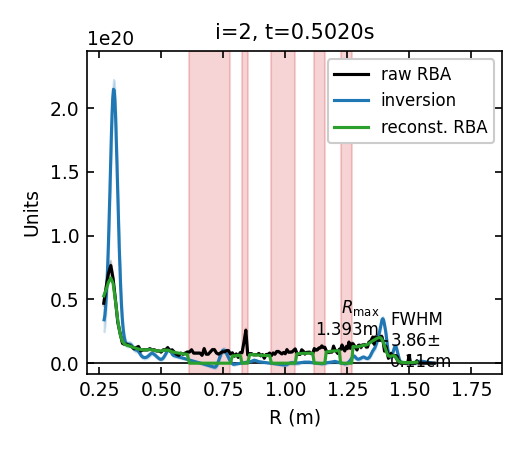

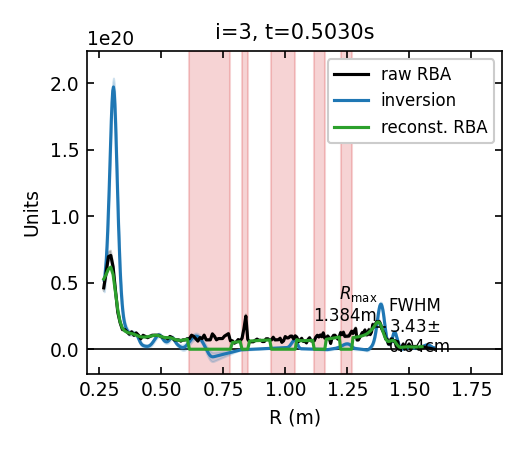

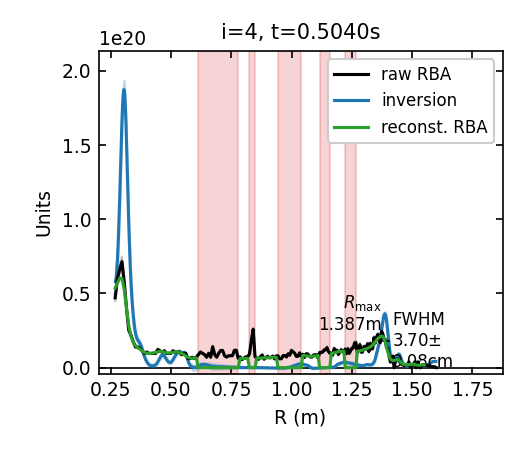

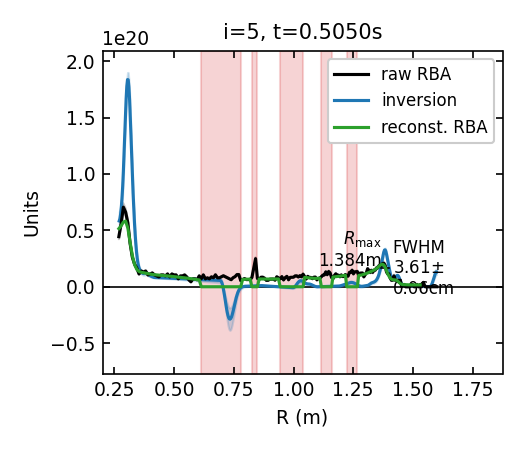

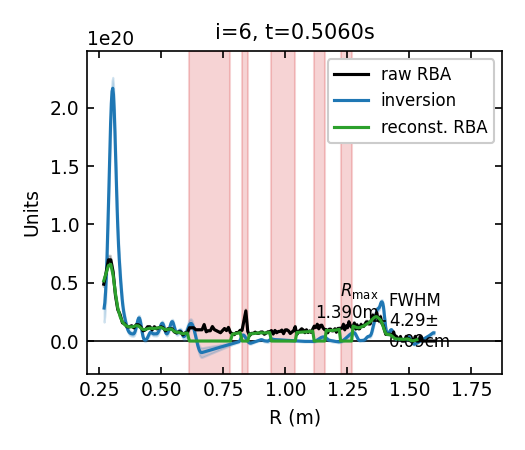

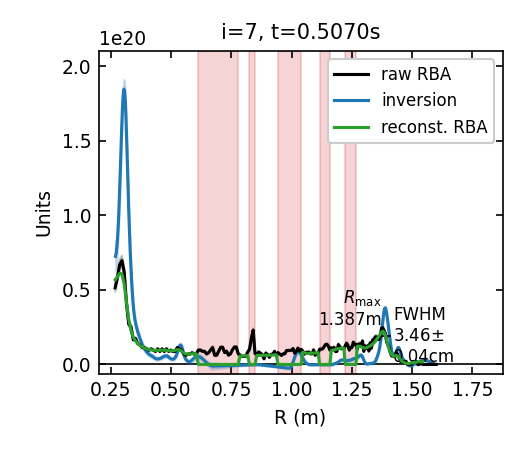

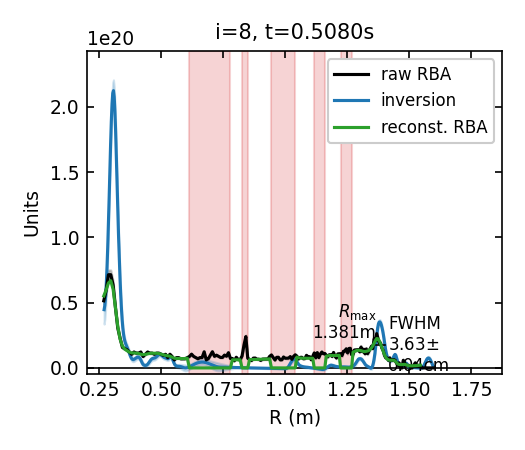

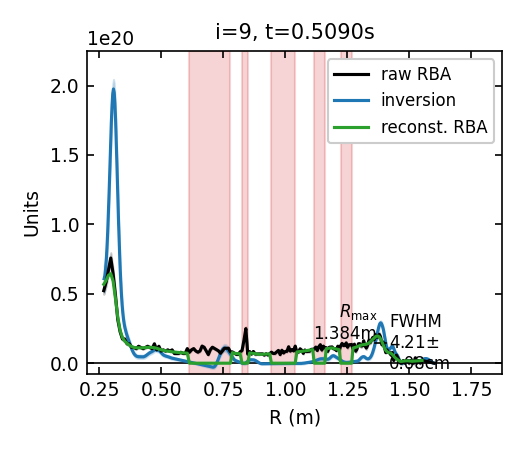

In [11]:
pf.plotInversion(
        R, data, err, RgridB, emissivity, emissivityErr, backprojection, time,
        emMaxR, emMax, emR0, emR1, emFWHM, emFWHMerr, fills
    )

In [12]:
import BESplotting as bp

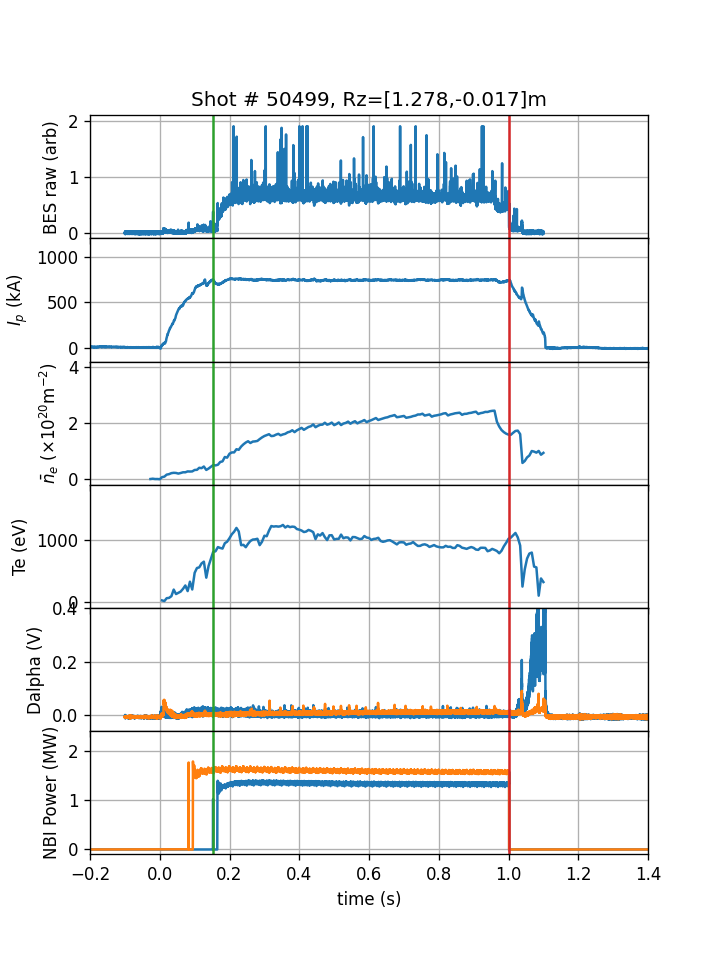

In [13]:
bp.subplotsBES(shotn)

In [14]:
I0, I1, J0, J1

(239, 240, 32, 216)